<a href="https://colab.research.google.com/github/Zukhriddin/Digital-Economy---WIUT-Fall-2026/blob/main/DE_seminar_TW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Digital Economy — Seminar 2, Teaching Week 2: Answer Guide**

## ***Section 1 — MCQ Answers (19 questions)***

1. B — It's Definition 1.1, word for word — ICT broadly: internet, mobile networks, cloud, IoT, even crypto. Not just “e-commerce” or “tech companies.”
2. B — Don't overthink these six labels — they're six spotlights on the same object, not six different objects.
3. B — The whole point of the lecture: this isn't really about tech firms — it's about everyone else using tech.
4. B — Digitization is the “how.” The digital economy is what happens because of it.
5. C — Interest rates snuck in as the odd one out — the real five are search, reproduction, transportation, tracking, verification.
6. B — Cheaper, easier price comparison online — that's a search-cost story.
7. C — Trusting a total stranger with your card details is a verification problem, solved by reputation systems, not a search problem.
8. B — Wikipedia works because copying a file costs next to nothing — that's reproduction cost, not search or tracking.
9. A — Watching what you do so the platform can guess what you'll want next — that's tracking, plain and simple.
10. B — Moore first said “doubles every year,” then quietly corrected himself in 1975 to “every two years.”
11. B — n² is the whole idea — value grows faster than membership does.
12. A — Standard Oil proves bigness isn't a trick tech companies invented — it happened a century before “network effects” was even a phrase.
13. C — eBay and Amazon basically invented the digital marketplace as we know it — textbook Internet Era.
14. D — Stock market cap was the distractor — the three real approaches are ICT-sector, national accounts, and consumer-surplus/welfare.
15. C — “Progressive taxation” has nothing to do with digital markets — that one's a giveaway once you spot it.
16. B — ISPs compete with other ISPs, not with Netflix — that's the entire net neutrality argument in one sentence.
17. C — Telecoms sit at the bottom layer — they're the pipes, not the apps.
18. B — Most of Uzbekistan's “digital economy” number isn't a tech sector at all — it's everyone else going digital.
19. B — Same story as CD-to-streaming, just with taxis: search costs collapse, and the platform gets data as a bonus.

## ***Section 2 - Applied Problems (3 Problems)***

### Problem 1 -- Moore's Law: Fit a Curve, Then Test It
Before running: download the CSV from
https://ourworldindata.org/grapher/transistors-per-microprocessor
(click Download -> CSV or you can use direct codes suggested in the website) and put it in the same folder as this script.

***Conclusion***: Moore's Law holds up remarkably well — the orange test-set points (2005–2021) sit almost exactly on the dashed line fitted purely from 1971–2005 data, with no visible slowdown even out to 2021.

In [13]:
import pandas as pd
import requests

# Fetch the data as suggested in the website.
df = pd.read_csv("https://ourworldindata.org/grapher/transistors-per-microprocessor.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/transistors-per-microprocessor.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()


Fitted model: Transistors = 2.145e-293 * exp(0.3457 * Year)
Implied doubling time: 2.00 years

Test-set predictions vs. reality:
 year  transistors    Predicted   PctError
 2006 5.829416e+08 3.458976e+08 -40.663415
 2007 8.058422e+08 4.887659e+08 -39.347199
 2008 8.058422e+08 6.906438e+08 -14.295400
 2009 2.308241e+09 9.759047e+08 -57.720856
 2010 2.308241e+09 1.378989e+09 -40.258041
 2011 2.600000e+09 1.948561e+09 -25.055354
 2012 2.600000e+09 2.753387e+09   5.899494
 2013 5.000000e+09 3.890635e+09 -22.187297
 2014 5.700000e+09 5.497608e+09  -3.550735
 2016 8.000000e+09 1.097692e+10  37.211445
 2017 1.920000e+10 1.551078e+10 -19.214695
 2018 2.110000e+10 2.191729e+10   3.873416
 2019 3.950000e+10 3.096992e+10 -21.595128
 2020 3.950000e+10 4.376162e+10  10.788918
 2021 5.820000e+10 6.183675e+10   6.248720


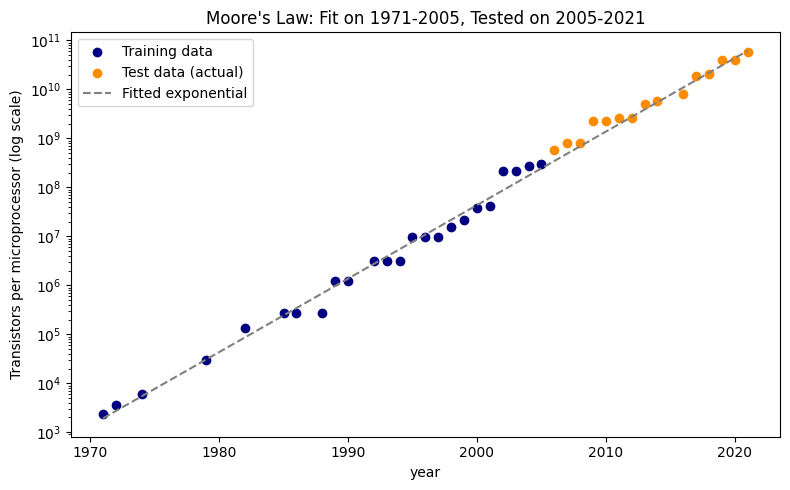

In [14]:
import numpy as np
import matplotlib.pyplot as plt

df = df[["year", "transistors"]].dropna()

# 2. Split into training and test sets ---------------------------------------
train = df[(df["year"] >= 1971) & (df["year"] <= 2005)]
test = df[(df["year"] > 2005) & (df["year"] <= 2021)]

# 3. Fit an exponential curve: Transistors = a * exp(b * Year) ---------------
#    Trick: take the log of Transistors, then it's just a straight-line fit.
b, log_a = np.polyfit(train["year"], np.log(train["transistors"]), 1)
a = np.exp(log_a)
print(f"\nFitted model: Transistors = {a:.3e} * exp({b:.4f} * Year)")

# 4. Doubling time implied by the fit -----------------------------------------
doubling_time = np.log(2) / b
print(f"Implied doubling time: {doubling_time:.2f} years")

# 5. Predict the test years and compare to what actually happened ------------
test = test.copy()
test["Predicted"] = a * np.exp(b * test["year"])
test["PctError"] = 100 * (test["Predicted"] - test["transistors"]) / test["transistors"]
print("\nTest-set predictions vs. reality:")
print(test[["year", "transistors", "Predicted", "PctError"]].to_string(index=False))

# 6. Plot ----------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(train["year"], train["transistors"], label="Training data", color="navy")
plt.scatter(test["year"], test["transistors"], label="Test data (actual)", color="darkorange")
years_fit = np.linspace(1971, 2021, 200)
plt.plot(years_fit, a * np.exp(b * years_fit), "--", color="gray", label="Fitted exponential")
plt.yscale("log")
plt.xlabel("year")
plt.ylabel("Transistors per microprocessor (log scale)")
plt.title("Moore's Law: Fit on 1971-2005, Tested on 2005-2021")
plt.legend()
plt.tight_layout()
plt.savefig("problem1_moores_law.png", dpi=150)
plt.show()

### Problem 2 -- Metcalfe's Law: Wikipedia's Early Growth, 2003-2007

Before running: export monthly Active Editors data for English Wikipedia from
https://stats.wikimedia.org/#/en.wikipedia.org/contributing/active-editors/normal|line|all|(page_type)~content*non-content|monthly
and save it as "active_editors_enwiki.csv" in the same folder as this script.
The Wikimedia Foundation revenue figures below are already known -- no need to
look those up separately.

***Conclusion***: Metcalfe's Law roughly holds in the early years (2003–06), but breaks down at the end — editor count actually fell slightly from 2006–07 to 2007–08 while revenue nearly doubled. So network size alone doesn't explain Wikipedia's revenue growth in this period; something else (likely better fundraising, plus a fast-growing reader base rather than editor base) is doing the work instead.

Columns in the file: ['month', 'total.total', 'timeRange.start', 'timeRange.end']

Yearly data used in the fit:
FiscalYear  ActiveEditors  Revenue
   2003-04    1992.750000    80129
   2004-05    7272.166667   379088
   2005-06   27167.666667  1508039
   2006-07   55469.333333  2734909
   2007-08   52495.083333  5032981

Fitted model: Revenue = 0.001192 * (Active Editors)^2 + 367645.74
R-squared: 0.769
(With only 5 points, treat this as a demonstration, not a robust test.)


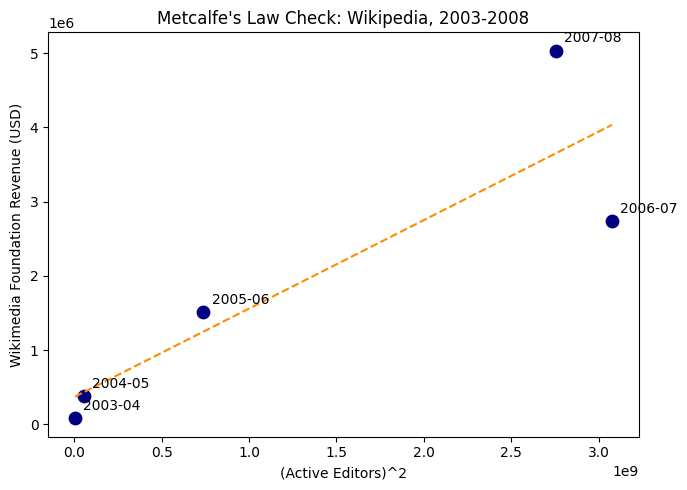

In [15]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt

# 1. Load the Active Editors data you downloaded ------------------------------
editors = pd.read_csv("active_editors_enwiki.csv")
print("Columns in the file:", list(editors.columns))

# Parse "month" as a real date, and pull the actual editor count out of
# "total.total". utc=True handles the trailing "Z" (UTC) in the timestamps.
editors["month"] = pd.to_datetime(editors["month"], utc=True)
editors = editors.rename(columns={"total.total": "ActiveEditors"})
editors = editors[["month", "ActiveEditors"]]

# 2. Keep only the years this exercise actually needs (2003-2008) ------------
editors = editors[(editors["month"] >= "2003-07-01") & (editors["month"] <= "2008-06-30")]

# 3. The Wikimedia Foundation's fiscal year runs July-June --------------------
def fiscal_year(d):
    return f"{d.year}-{str(d.year + 1)[-2:]}" if d.month >= 7 else f"{d.year - 1}-{str(d.year)[-2:]}"

editors["FiscalYear"] = editors["month"].apply(fiscal_year)

# 4. Average the monthly editor counts within each fiscal year ---------------
yearly = editors.groupby("FiscalYear")["ActiveEditors"].mean().reset_index()

# 5. Attach the known Wikimedia Foundation revenue figures --------------------
revenue = {
    "2003-04": 80129,
    "2004-05": 379088,
    "2005-06": 1508039,
    "2006-07": 2734909,
    "2007-08": 5032981,
}
yearly["Revenue"] = yearly["FiscalYear"].map(revenue)
yearly = yearly.dropna()
print("\nYearly data used in the fit:")
print(yearly.to_string(index=False))

# 6. Metcalfe proxy: (Active Editors) squared ---------------------------------
yearly["EditorsSquared"] = yearly["ActiveEditors"] ** 2

# 7. Fit a straight line: Revenue = m * EditorsSquared + c --------------------
m, c = np.polyfit(yearly["EditorsSquared"], yearly["Revenue"], 1)
r2 = np.corrcoef(yearly["EditorsSquared"], yearly["Revenue"])[0, 1] ** 2
print(f"\nFitted model: Revenue = {m:.6f} * (Active Editors)^2 + {c:.2f}")
print(f"R-squared: {r2:.3f}")
print("(With only 5 points, treat this as a demonstration, not a robust test.)")

# 8. Plot -----------------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(yearly["EditorsSquared"], yearly["Revenue"], color="navy", s=80)
for _, row in yearly.iterrows():
    plt.annotate(row["FiscalYear"], (row["EditorsSquared"], row["Revenue"]),
                 textcoords="offset points", xytext=(6, 6))
x_fit = np.linspace(yearly["EditorsSquared"].min(), yearly["EditorsSquared"].max(), 100)
plt.plot(x_fit, m * x_fit + c, "--", color="darkorange")
plt.xlabel("(Active Editors)^2")
plt.ylabel("Wikimedia Foundation Revenue (USD)")
plt.title("Metcalfe's Law Check: Wikipedia, 2003-2008")
plt.tight_layout()
plt.savefig("problem2_metcalfes_law.png", dpi=150)
plt.show()

### Problem 3 -- The Marginal Benefit of Joining a Network

No external data needed -- this is a self-contained model.

***Conclusion***: The marginal benefit of joining a network rises in a perfectly straight line — 1, 3, 5, 7, 9… up to 39 at n = 20 — increasing by exactly 2v with every single new join. That's the visible fingerprint of n² growth: total value curves upward, but the extra value from each additional user grows steadily rather than leveling off, which is precisely why networks become so much more valuable as they scale rather than just proportionally more valuable.

The externality result is the more important takeaway, though. When the 11th user joins a network of 10, they personally gain v·10 — but they also hand out v·10 in total, split one unit of value each, to the 10 people already there. That's an exact 50/50 split between what the new user captures and what they give away for free. Because that new user only ever weighs their own half when deciding whether joining is worth it, networks will naturally attract fewer users than would actually be efficient for the group as a whole — nobody is paying them for the value they create for strangers. This is exactly the gap that referral bonuses, free trials, and early-user subsidies (Dropbox, Uber) are designed to close: the platform effectively pays new users for the externality, nudging their private decision closer to what's actually best for the network.

 n  TotalBenefit  MarginalBenefit
 1             1                1
 2             4                3
 3             9                5
 4            16                7
 5            25                9
 6            36               11
 7            49               13
 8            64               15
 9            81               17
10           100               19
11           121               21
12           144               23
13           169               25
14           196               27
15           225               29
16           256               31
17           289               33
18           324               35
19           361               37
20           400               39

When user 11 joins a network of 10 existing users:
  Benefit they capture for themselves:        10
  Benefit they create for existing users:      10
  Total new value created by this one join:    20
  Share captured by the new user:               50%


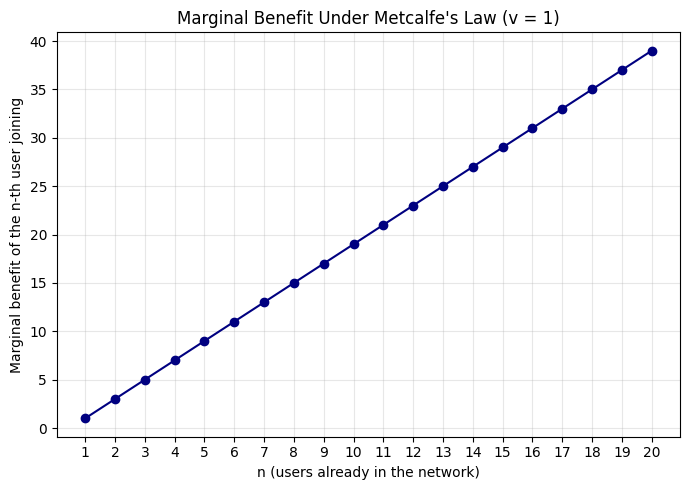

In [16]:
#import numpy as np
#import pandas as pd
#import matplotlib.pyplot as plt

v = 1  # value per connection -- change this to any constant you like
n = np.arange(1, 21)  # network sizes 1 through 20

# 1. Total benefit across all n users: v * n^2 --------------------------------
total_benefit = v * n ** 2

# 2. Marginal benefit of the n-th user joining: TotalBenefit(n) - TotalBenefit(n-1)
marginal_benefit = total_benefit - np.append(0, total_benefit[:-1])

table = pd.DataFrame({
    "n": n,
    "TotalBenefit": total_benefit,
    "MarginalBenefit": marginal_benefit,
})
print(table.to_string(index=False))
# Notice: MarginalBenefit is just the odd numbers (1, 3, 5, 7, ...) -- it rises
# in a perfectly straight line, increasing by exactly 2*v every time.

# 3. The externality: what a new user creates for themselves vs. for others --
n_existing = 10  # try changing this to see the pattern hold at any size
own_benefit = v * n_existing          # the new (n+1)-th user's own benefit
externality = v * n_existing          # extra benefit created for the n existing users, summed
print(f"\nWhen user {n_existing + 1} joins a network of {n_existing} existing users:")
print(f"  Benefit they capture for themselves:        {own_benefit}")
print(f"  Benefit they create for existing users:      {externality}")
print(f"  Total new value created by this one join:    {own_benefit + externality}")
print(f"  Share captured by the new user:               {own_benefit / (own_benefit + externality):.0%}")

# 4. Plot marginal benefit -----------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(n, marginal_benefit, marker="o", color="navy")
plt.xlabel("n (users already in the network)")
plt.ylabel("Marginal benefit of the n-th user joining")
plt.title("Marginal Benefit Under Metcalfe's Law (v = 1)")
plt.xticks(n)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("problem3_marginal_benefit.png", dpi=150)
plt.show()

## ***Section 3 - Discussion Questions***

### Question 1 — Where does the five-costs logic break down?

There's no single right answer here — the value is in the argument. A few genuinely defensible directions students tend to land on:
•  Trust built on long personal relationships — a family doctor, a decades-long business partner. Verification costs were never really the barrier there, so digitizing the relationship doesn't remove much friction.
•  Highly local, hyper-perishable services — a haircut, a live music performance. Transportation and reproduction costs don't apply in any meaningful way, because the thing being bought can't be moved or copied at all.
•  Anything where the cost was never economic in the first place — e.g. cultural or religious taboos around a transaction. No falling cost fixes a barrier that was never about cost.
Push back gently on weak answers (“grocery shopping”, “buying a car”) — in almost every case, at least one of the five costs actually has fallen (search costs especially), even if others haven't. The good answers require genuinely defending all five, not just noticing one hasn't moved.

### Question 2 — Digitized industry: pros and cons

Whatever industry they pick, listen for a real, specific downside — not a generic “some people don't like change.” A few strong examples if groups get stuck:
•  Taxis → ride-hailing: drivers gained flexibility but lost the guaranteed income and benefits that came with medallions/employment; riders gained convenience but algorithmic surge pricing can be opaque and feel exploitative during emergencies.
•  Journalism: readers gained free, instant access to more sources; the industry lost the advertising revenue that used to fund investigative reporting, and “free” often means an attention-economy business model instead.
•  Banking: digitization cut costs and expanded access (relevant to Uzbekistan's own fintech push), but it also concentrated a lot of personal financial data in a few platforms — a real privacy and systemic-risk trade-off.
The point of the question is to stop students from treating digitization as an unambiguous good — a good answer names who wins, who loses, and why those aren't the same people.